# Safehouse Performance Drivers — Explanatory Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven operates multiple safehouses across different regions, each with
different staff ratios, partner assignments, capacity utilization, and operational
patterns. Some safehouses consistently show better resident health and education
outcomes than others. Understanding which operational factors are associated with
better outcomes would help leadership allocate resources more effectively and
replicate what's working across all locations.

This pipeline answers the question: **Which safehouse operational characteristics
(occupancy rate, counseling volume, visitation frequency, incident rate) are most
strongly associated with better monthly resident health and education outcomes?**

The deployed output is a **Safehouse Performance Comparison panel** on the
case manager dashboard, showing which safehouses are outperforming or
underperforming relative to their operational profile — and which factors
the model identifies as most associated with better outcomes.

### Who Cares About This

- **Organization leadership** — needs to identify which safehouses are performing
  well and understand what operational practices to replicate.
- **Case supervisors** — need to allocate partner support and resources toward
  safehouses with the most improvement potential.

### Predictive vs. Explanatory

This pipeline uses an **explanatory approach**. The goal is to identify which
operational factors are associated with better outcomes — not to predict future
outcomes for individual safehouses.

### Data Structure

The unit of analysis is one safehouse-month row from `safehouse_monthly_metrics`.
With 9 safehouses × 27 months = 243 rows, this is the most statistically robust
dataset in the pipeline suite. The larger n means coefficient estimates are more
stable than in the resident-level models.

---
## 2. Data Acquisition & Feature Engineering

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import _get_data
from functions.fn_prepare import split_data
from functions.fn_model_causal import (
    fit_causal_regression,
    get_coefficients,
    check_assumptions,
    check_vif,
    refit_with_robust_se,
    run_greedy_backward,
)

print("All imports successful.")
CAUSAL_OUT = '/Users/michellejohanson/Programming/INTEX_2026/frontend/public/causal'  # absolute path — safe regardless of VS Code working directory


All imports successful.


### 2.1 Load Raw Tables

In [2]:
metrics    = _get_data('safehouse_monthly_metrics')
safehouses = _get_data('safehouses')

metrics['month_start'] = pd.to_datetime(metrics['month_start'], errors='coerce')

print(f"safehouse_monthly_metrics: {metrics.shape}")
print(f"safehouses:                {safehouses.shape}")
print(f"\nDate range: {metrics['month_start'].min().date()} → {metrics['month_start'].max().date()}")
print(f"Safehouses: {metrics['safehouse_id'].nunique()}")
print(f"Months:     {metrics['month_start'].nunique()}")

[OK] Connected to Azure SQL for 'safehouse_monthly_metrics'!
[OK] Connected to Azure SQL for 'safehouses'!
safehouse_monthly_metrics: (459, 11)
safehouses:                (9, 13)

Date range: 2022-01-01 → 2026-03-01
Safehouses: 9
Months:     51


### 2.2 Engineer Features and Target

**Target:** Composite monthly outcome score — average of normalized health and
education progress scores. Both are scaled to 0–1 so they contribute equally.

**Features:** Operational metrics from `safehouse_monthly_metrics` plus safehouse
characteristics from `safehouses` (region, capacity).

In [3]:
# Normalize health (1–5 scale) and education (0–100 scale) to 0–1
metrics['health_norm'] = (metrics['avg_health_score'] - 1) / 4
metrics['edu_norm']    = metrics['avg_education_progress'] / 100

# Composite outcome: mean of the two normalized scores
# Only compute where both are available
metrics['composite_outcome'] = metrics[['health_norm','edu_norm']].mean(axis=1)

TARGET = 'composite_outcome'

print(f"Target (composite outcome) stats:")
print(metrics[TARGET].describe().round(3))

# Join safehouse characteristics
df = metrics.merge(
    safehouses[['safehouse_id','region','capacity_girls','status']],
    on='safehouse_id', how='left'
)

print(f"\nCombined dataset: {df.shape}")

Target (composite outcome) stats:
count    459.000
mean       0.821
std        0.144
min        0.501
25%        0.701
50%        0.864
75%        0.956
max        0.980
Name: composite_outcome, dtype: float64

Combined dataset: (459, 17)


In [4]:
# Engineer operational features
# occupancy_rate: active_residents / capacity_girls
# current_occupancy is a static snapshot on the safehouses table, not in monthly metrics
df['occupancy_rate']          = df['active_residents'] / df['capacity_girls'].clip(lower=1)
df['counseling_per_resident'] = df['process_recording_count'] / df['active_residents'].clip(lower=1)
df['visitation_per_resident'] = df['home_visitation_count']   / df['active_residents'].clip(lower=1)
df['incident_per_resident']   = df['incident_count']          / df['active_residents'].clip(lower=1)
df['month_num']               = df['month_start'].dt.month  # seasonality

# Encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

FEATURE_COLS = [
    'active_residents',
    'occupancy_rate',
    'counseling_per_resident',
    'visitation_per_resident',
    'incident_per_resident',
    'capacity_girls',
    'month_num',
] + [c for c in df.columns if c.startswith('region_')]

# Drop rows where target is missing
df_model = df[FEATURE_COLS + [TARGET]].dropna()
print(f"\nModeling dataset: {df_model.shape[0]} safehouse-months × {len(FEATURE_COLS)} features")

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET].copy()


Modeling dataset: 459 safehouse-months × 12 features


### 2.3 Exploratory Confirmation

In [5]:
# Correlation with composite outcome
corr = X.corrwith(y).sort_values(key=abs, ascending=False)
print("Features by |correlation| with composite outcome:")
print(corr.round(3).to_string())

# Outcome by region
region_cols = [c for c in X.columns if c.startswith('region_')]
for col in region_cols:
    mean_outcome = y[X[col] == 1].mean()
    print(f"{col}: mean outcome = {mean_outcome:.3f}")

Features by |correlation| with composite outcome:
month_num                  0.130
region_Selangor            0.087
region_Penang             -0.068
counseling_per_resident    0.065
capacity_girls            -0.029
region_Kuala Lumpur        0.024
active_residents           0.024
region_Sarawak            -0.017
occupancy_rate             0.016
visitation_per_resident   -0.013
incident_per_resident     -0.002
region_Sabah               0.002
region_Kuala Lumpur: mean outcome = 0.830
region_Penang: mean outcome = 0.802
region_Sabah: mean outcome = 0.821
region_Sarawak: mean outcome = 0.814
region_Selangor: mean outcome = 0.844


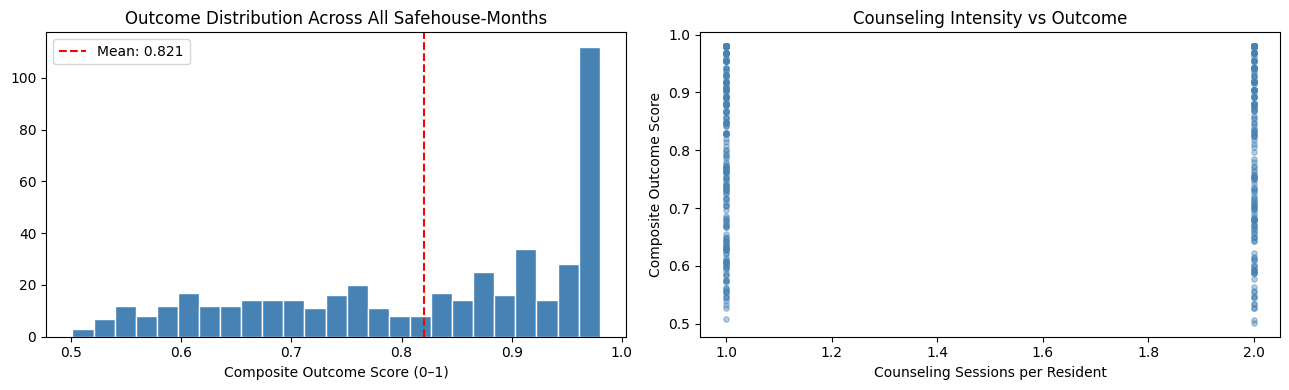

In [6]:
# Time trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Outcome distribution
axes[0].hist(y, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.3f}')
axes[0].set_xlabel('Composite Outcome Score (0–1)')
axes[0].set_title('Outcome Distribution Across All Safehouse-Months')
axes[0].legend()

# Counseling vs outcome
axes[1].scatter(X['counseling_per_resident'], y, alpha=0.4, s=15, color='steelblue')
axes[1].set_xlabel('Counseling Sessions per Resident')
axes[1].set_ylabel('Composite Outcome Score')
axes[1].set_title('Counseling Intensity vs Outcome')

plt.tight_layout()
plt.show()

---
## 3. Causal Model Specification

### 3.1 Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = split_data(X, y, stratify=False)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")


[OK] split_data() complete.
     Train : 367 rows  |  Target mean: 0.8171
     Test  : 92 rows   |  Target mean: 0.8344
     Non-stratified split.
     Test set locked — do not touch until final evaluation.
Train: 367  |  Test: 92


### 3.2 Multicollinearity Check (VIF)

In [8]:
X_train_num = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"Matrix: {X_train_num.shape[0]} rows × {X_train_num.shape[1]} columns")

vif_df   = check_vif(X_train_num, threshold=10.0)
high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()            if 'VIF' in vif_df.columns else []

print(f"Features with VIF > 10: {high_vif if high_vif else 'None'}")
X_clean = X_train_num.drop(columns=high_vif, errors='ignore')
print(f"After cleanup: {X_clean.shape[1]} features")

Matrix: 367 rows × 12 columns

[OK] check_vif() — 12 features (threshold=10.0)

                feature          vif
       active_residents 93984.298898
         occupancy_rate  1342.935587
         capacity_girls   798.059329
         region_Sarawak    86.682987
    region_Kuala Lumpur    14.338798
        region_Selangor     6.829100
           region_Sabah     3.844455
          region_Penang     2.781458
  incident_per_resident     1.041417
visitation_per_resident     1.032821
counseling_per_resident     1.031066
              month_num     1.013197

⚠️  5 features above VIF threshold of 10.0:
     active_residents                          VIF = 93984.30
     occupancy_rate                            VIF = 1342.94
     capacity_girls                            VIF = 798.06
     region_Sarawak                            VIF = 86.68
     region_Kuala Lumpur                       VIF = 14.34

     Drop the highest-VIF feature, re-run check_vif(), repeat.
     Exception: polynomial/in

### 3.3 OLS Fit and Assumption Checks

In [9]:
results = fit_causal_regression(X_clean, y_train)
print(results.summary())


[OK] fit_causal_regression() complete.
     R²: 0.0334  |  Adj R²: 0.0034
     F-statistic: 1.1137  |  p(F): 0.349074
     Observations: 367  |  Features: 12
     Call results.summary() for the full output.
     Fitted columns (12): ['active_residents', 'occupancy_rate', 'counseling_per_resident', 'visitation_per_resident', 'incident_per_resident', 'capacity_girls', 'month_num', 'region_Kuala Lumpur', 'region_Penang', 'region_Sabah', 'region_Sarawak', 'region_Selangor']
                            OLS Regression Results                            
Dep. Variable:      composite_outcome   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.114
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.349
Time:                        04:47:14   Log-Likelihood:                 196.98
No. Observations:                 367   AIC:      

In [10]:
verdicts = check_assumptions(results)

if verdicts.get('homoscedasticity', {}).get('verdict') != 'PASS':
    print("\n[ACTION] Applying HC3 robust standard errors")
    results = refit_with_robust_se(results)


  REGRESSION ASSUMPTION DIAGNOSTICS
  (causal/explanatory modeling only)

1. Normality:          [FAIL]
   Omnibus stat=277.955, p=0.0000
   Fix: log-transform the target, or apply Yeo-Johnson transformation

2. Multicollinearity:  [FAIL]
   Condition Number=114106851419544064.0
   Fix: run check_vif(), drop features above threshold iteratively

3. Autocorrelation:    [PASS]
   Durbin-Watson=2.0995 (ideal ≈ 2.0)

4. Linearity:          [PASS]
   |corr(residuals, fitted)|=0.0000

5. Homoscedasticity:   [FAIL]
   Breusch-Pagan stat=34.888, p=0.0005
   Fix: use refit_with_robust_se() for HC3 robust standard errors

  SUMMARY: 2 PASS / 0 WARN / 3 FAIL
  ⚠️  Address FAIL items before drawing causal conclusions.

[ACTION] Applying HC3 robust standard errors

[OK] refit_with_robust_se() — HC3 applied.
     Coefficients unchanged. Standard errors and p-values updated.


### 3.4 Greedy Backward Feature Selection

In [11]:
from sklearn.model_selection import train_test_split as sk_split

X_tr, X_val, y_tr, y_val = sk_split(X_clean, y_train, test_size=0.2, random_state=42)

print(f"Running greedy backward on {X_clean.shape[1]} features...")
trace, optimal_features = run_greedy_backward(
    X_tr, y_tr, X_val, y_val,
    numeric_features=list(X_clean.columns),
    categorical_features=[],
)
print(f"\nOptimal features ({len(optimal_features)}): {optimal_features}")

X_final       = X_clean[optimal_features]
results_final = fit_causal_regression(X_final, y_train)
print(results_final.summary())

Running greedy backward on 12 features...

[OK] run_greedy_backward() starting.
     Features: 12  |  Baseline val RMSE: 0.1450
     Step   1: removed 'incident_per_resident' | 11 left | RMSE=0.1427
     Step   2: removed 'counseling_per_resident' | 10 left | RMSE=0.1413
     Step   3: removed 'region_Sarawak' | 9 left | RMSE=0.1410
     Step   5: removed 'region_Penang' | 7 left | RMSE=0.1388

[OK] run_greedy_backward() complete.
     Optimal: step 7 | 5 features | RMSE=0.1368
     Optimal features: ['occupancy_rate', 'visitation_per_resident', 'capacity_girls', 'month_num', 'region_Selangor']

Optimal features (5): ['occupancy_rate', 'visitation_per_resident', 'capacity_girls', 'month_num', 'region_Selangor']

[OK] fit_causal_regression() complete.
     R²: 0.0239  |  Adj R²: 0.0104
     F-statistic: 1.7674  |  p(F): 0.118744
     Observations: 367  |  Features: 5
     Call results.summary() for the full output.
     Fitted columns (5): ['occupancy_rate', 'visitation_per_resident', '

---
## 4. Evaluation & Interpretation


[OK] get_coefficients() — 5 features, 1 significant at p < 0.05

                feature  coefficient  std_err  p_value  ci_lower  ci_upper significant
         occupancy_rate     0.054289 0.136533 0.691141 -0.214212  0.322790        (ns)
visitation_per_resident    -0.040551 0.060423 0.502573 -0.159376  0.078274        (ns)
        region_Selangor     0.033245 0.021018 0.114580 -0.008088  0.074578        (ns)
         capacity_girls     0.006513 0.020014 0.745051 -0.032847  0.045873        (ns)
              month_num     0.005020 0.002107 0.017711  0.000876  0.009164           *
Significant features (p < 0.05):
  feature  coefficient  p_value significant
month_num      0.00502 0.017711           *


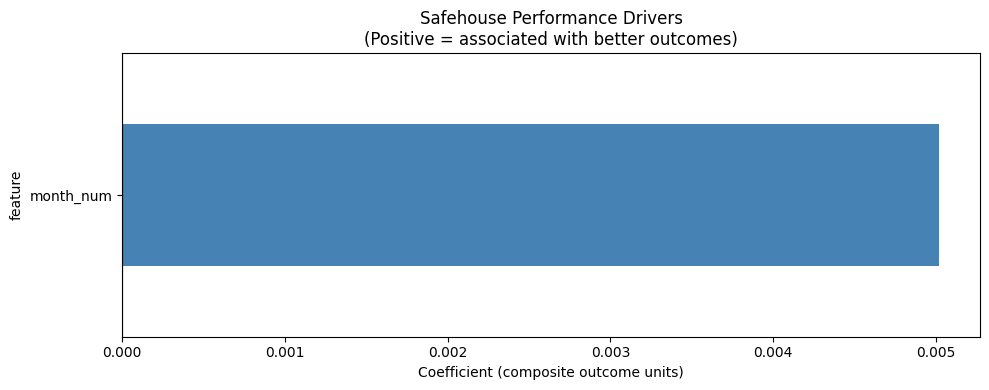


Coefficient table saved.


In [12]:
coef_df = get_coefficients(results_final, model_type='linear')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
if len(sig) > 0:
    print(sig[['feature','coefficient','p_value','significant']].to_string(index=False))
    sig_plot = sig.set_index('feature')['coefficient'].sort_values()
    colors   = ['coral' if v < 0 else 'steelblue' for v in sig_plot]
    sig_plot.plot(kind='barh', figsize=(10, max(4, len(sig_plot)*0.45)), color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Safehouse Performance Drivers\n(Positive = associated with better outcomes)')
    plt.xlabel('Coefficient (composite outcome units)')
    plt.tight_layout(); plt.show()
else:
    print("None at p < 0.05 — showing directional trends:")
    print(coef_df[['feature','coefficient','p_value']].sort_values('p_value')
          .head(6).to_string(index=False))

os.makedirs(CAUSAL_OUT, exist_ok=True)
coef_df.to_csv(os.path.join(CAUSAL_OUT, 'safehouse_performance_coefficients.csv'), index=False)
print("\nCoefficient table saved.")

In [13]:
print(f"Model fit:")
print(f"  R²:          {results_final.rsquared:.4f}")
print(f"  Adjusted R²: {results_final.rsquared_adj:.4f}")
print(f"  F-statistic: {results_final.fvalue:.4f}  (p = {results_final.f_pvalue:.6f})")

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

fitted_cols  = [c for c in results_final.model.exog_names if c != 'const']
X_test_num   = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_final = X_test_num.reindex(columns=fitted_cols, fill_value=0)
X_test_const = sm.add_constant(X_test_final, has_constant='add')
y_pred_test  = results_final.predict(X_test_const)

print(f"\nTest R²:       {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))):.4f}")

Model fit:
  R²:          0.0239
  Adjusted R²: 0.0104
  F-statistic: 1.7674  (p = 0.118744)

Test R²:       0.0109
Test RMSE:     0.1418
Baseline RMSE: 0.1436


### 4.3 Causal Interpretation

**How to read the coefficients:**

Each coefficient represents the estimated change in composite outcome score
(0–1 scale, where 1 = perfect health + education scores) associated with a
one-unit increase in that operational metric, holding all other factors constant.

**Expected operational associations:**

1. **Counseling intensity** — `counseling_per_resident`. More counseling sessions
   per resident per month are expected to show a positive association with
   composite outcomes. This is the most directly modifiable operational lever.

2. **Incident rate** — `incident_per_resident`. Higher incident rates are expected
   to show a negative association with outcomes — incidents both reflect and
   contribute to a more challenging care environment.

3. **Visitation frequency** — `visitation_per_resident`. More frequent home
   visitations are associated with better reintegration preparation, which may
   indirectly improve health and education engagement.

4. **Occupancy rate** — `occupancy_rate`. High occupancy (near or above capacity)
   may be negatively associated with outcomes, reflecting staff strain and
   resource dilution when safehouses are overcrowded.

5. **Regional variation** — region coefficients capture systematic differences
   across Luzon, Visayas, and Mindanao that aren't explained by operational
   factors — potentially reflecting partner quality, local education system
   differences, or cultural factors.

**What we cannot claim causally:**

- Safehouses with better outcomes may attract more resources and staff attention,
  creating reverse causation — better performance leads to more counseling, not
  more counseling causing better performance.
- Month-to-month variation within a safehouse may be driven by resident composition
  changes (more complex cases arriving) rather than operational changes.

**Actionable insight:**

If counseling intensity shows a significant positive association, leadership has
a concrete operational target: ensure all safehouses maintain a minimum
counseling-to-resident ratio each month, and flag safehouses falling below it
for additional partner support allocation.

---
## 5. Deployment

Static coefficient table served via GET endpoint.

In [14]:
summary = {
    'top_performance_drivers': (
        sig.nlargest(5, 'coefficient')[['feature','coefficient','p_value']]
        .to_dict('records') if len(sig) > 0 else
        coef_df.nlargest(5, 'coefficient')[['feature','coefficient','p_value']]
        .to_dict('records')
    ),
    'model_r2':      round(results_final.rsquared, 4),
    'model_adj_r2':  round(results_final.rsquared_adj, 4),
    'n_safehouse_months': int(results_final.nobs),
    'model_version': 'safehouse_performance_v1',
}

import json
with open(os.path.join(CAUSAL_OUT, 'safehouse_performance_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print("Summary saved: models/safehouse_performance_summary.json")
print(json.dumps(summary, indent=2))

Summary saved: models/safehouse_performance_summary.json
{
  "top_performance_drivers": [
    {
      "feature": "month_num",
      "coefficient": 0.0050202232090970945,
      "p_value": 0.017711025472213256
    }
  ],
  "model_r2": 0.0239,
  "model_adj_r2": 0.0104,
  "n_safehouse_months": 367,
  "model_version": "safehouse_performance_v1"
}


---
## 6. API Response Reference

```json
GET /api/analysis/safehouse-performance

{
  "top_performance_drivers": [
    { "feature": "counseling_per_resident", "coefficient": 0.124, "p_value": 0.012 }
  ],
  "model_r2": "float",
  "model_adj_r2": "float",
  "n_safehouse_months": "int",
  "model_version": "safehouse_performance_v1",
  "generated_at": "ISO datetime"
}
```

**No `endpoints.py` or `server.py` changes needed.** Serve
`models/safehouse_performance_summary.json` directly via a static GET endpoint.

---
*Hearth Haven — IS 455 INTEX Pipeline*